# Практическая работа №5. Библиотека Pandas. Визуальный анализ данных

## Комплексное задание №1. Применение основных методов для анализа данных

1. Скачайте этот блокнот к себе.
2. Заполните пропущенные ячейки, отвечая на заданные вопросы. Там должен быть код! (если не сказано обратное)
3. Сохраните результат в своём гитхаб репозитории.

#### Полезная литература
- [**Блокнот с теорией**](https://colab.research.google.com/drive/1SLqmaYz4xEsxVV-LGwb3ityheBTzHJQu?usp=sharing)
- http://pandas.pydata.org/pandas-docs/stable/10min.html
- https://pandas.pydata.org/pandas-docs/stable/indexing.html
- https://pandas.pydata.org/pandas-docs/stable/missing_data.html

В этом задании мы с Вами рассмотрим датасет [Adult Data Set](https://archive.ics.uci.edu/ml/datasets/Adult).
Основывается он на данных переписи населения 1994 года в США.

Расшифровка содержимого колонок:

- age: continuous.
- workclass: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.
- fnlwgt: continuous. sampling weight, more here: SIPP Weighting.
- education: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool.
- education-num: continuous.
- marital-status: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse.
- occupation: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces.
- relationship: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.
- race: White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black.
- sex: Female, Male.
- capital-gain: continuous. Income from investment sources, apart from wages/salary.
- capital-loss: continuous. Losses from investment sources, apart from wages/salary.
- hours-per-week: continuous.
- native-country: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands.

In [272]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
pd.__version__

'3.0.1'

Если вы увидели warning, не переживайте, всё хорошо.
- https://stackoverflow.com/questions/40845304/runtimewarning-numpy-dtype-size-changed-may-indicate-binary-incompatibility
- https://github.com/numpy/numpy/pull/432

In [273]:
columns='age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income'.split(',')
df = pd.read_csv('assets/adult.data', na_values=' ?', names = columns) # можно загрузить из файла или URL
# df = pd.read_csv('https://archive.ics.uci.edu/static/public/2/adult.zip', compression='zip', na_values=' ?')

In [274]:
df.head(10)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


1) Выведите последние 10 элеметнов датасета

In [275]:
df.tail(10)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
32551,32,Private,34066,10th,6,Married-civ-spouse,Handlers-cleaners,Husband,Amer-Indian-Eskimo,Male,0,0,40,United-States,<=50K
32552,43,Private,84661,Assoc-voc,11,Married-civ-spouse,Sales,Husband,White,Male,0,0,45,United-States,<=50K
32553,32,Private,116138,Masters,14,Never-married,Tech-support,Not-in-family,Asian-Pac-Islander,Male,0,0,11,Taiwan,<=50K
32554,53,Private,321865,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,>50K
32555,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


2) Сколько колонок и сколько строк в этом датасете?

In [276]:
df.shape

(32561, 15)

3) Какие типы данных у элементов этого датасета?

In [277]:
df.dtypes

age               int64
workclass           str
fnlwgt            int64
education           str
education.num     int64
marital.status      str
occupation          str
relationship        str
race                str
sex                 str
capital.gain      int64
capital.loss      int64
hours.per.week    int64
native.country      str
income              str
dtype: object

4) Какие признаки имеют пропуски?

In [278]:
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

5) Как вы думаете, с чем связаны пропуски этих значение. Напишите развернутый ответ в ячейке ниже.

Ваш ответ: cвязано это может быть с тем, что для определенных признаков например как workclass, occupation и native.country просто не нашлось нужного ответа из предложенных в датасете, поэтому не имея альтернативы, ячейки оставили пустыми

6) Какие и сколько различных рабочих классов workclass представлено в выборке?

In [279]:
a = set(df['workclass'])
print(a)
print(len(a))
print('\n\n\n')

print(df['workclass'].unique())
print(len(df['workclass'].unique()))

{nan, ' Private', ' Self-emp-not-inc', ' Without-pay', ' Local-gov', ' State-gov', ' Self-emp-inc', ' Federal-gov', ' Never-worked'}
9




<StringArray>
[       ' State-gov', ' Self-emp-not-inc',          ' Private',
      ' Federal-gov',        ' Local-gov',                 nan,
     ' Self-emp-inc',      ' Without-pay',     ' Never-worked']
Length: 9, dtype: str
9


7) Какой средний возраст женщин и мужчин?

In [280]:
df_1 = df
mask_1 = df_1['sex'] == ' Male'
mask_2 = df_1['sex'] == ' Female'
print(df_1['age'][mask_1].mean())
print(df_1['age'][mask_2].mean())


39.43354749885268
36.85823043357163


8) Постройте гистограмму(bar) распределения образования людей (education)

<StringArray>
[   ' Bachelors',      ' HS-grad',         ' 11th',      ' Masters',
          ' 9th', ' Some-college',   ' Assoc-acdm',    ' Assoc-voc',
      ' 7th-8th',    ' Doctorate',  ' Prof-school',      ' 5th-6th',
         ' 10th',      ' 1st-4th',    ' Preschool',         ' 12th']
Length: 16, dtype: str


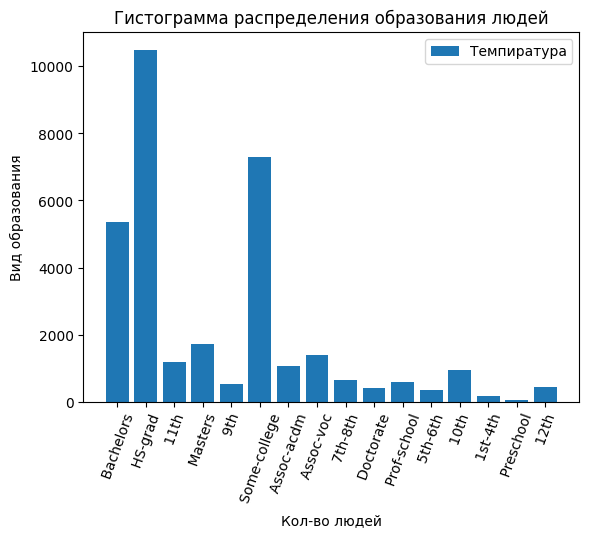

In [281]:
print(df['education'].unique())
a = []
all_education = [   ' Bachelors',      ' HS-grad',         ' 11th',      ' Masters',
          ' 9th', ' Some-college',   ' Assoc-acdm',    ' Assoc-voc',
      ' 7th-8th',    ' Doctorate',  ' Prof-school',      ' 5th-6th',
         ' 10th',      ' 1st-4th',    ' Preschool',         ' 12th']
for education in all_education:
    a.append((df['education'] == education).sum())
plt.bar(all_education, a, label = 'Темпиратура')
plt.legend()
plt.title('Гистограмма распределения образования людей')
plt.xlabel("Кол-во людей")
plt.ylabel('Вид образования')
plt.xticks(rotation=70)
plt.show()

9) Каковы средние значения и среднеквадратичные отклонения возраста тех, кто получает более 50K в год (признак income) и тех, кто получает менее 50K в год?

In [282]:
mask_1 = df['income'] == ' >50K'
mask_2 = df['income'] == ' <=50K'
print('Те кто получают более 50К:')
print('\t- ', df['age'][mask_1].mean(), "(среднее значение)")
print('\t- ', df['age'][mask_1].std(), "(среднеквадратичное отклонение)")
print('Те кто получают менее 50К:')
print('\t- ', df['age'][mask_2].mean(), "(среднее значение)")
print('\t- ', df['age'][mask_2].std(), "(среднеквадратичное отклонение)")

Те кто получают более 50К:
	-  44.24984058155847 (среднее значение)
	-  10.519027719851826 (среднеквадратичное отклонение)
Те кто получают менее 50К:
	-  36.78373786407767 (среднее значение)
	-  14.02008849082488 (среднеквадратичное отклонение)


10) Правда ли, что люди, которые получают больше 50k, имеют как минимум высшее образование? (признак education - Bachelors, Prof-school, Assoc-acdm, Assoc-voc, Masters или Doctorate)

In [283]:
df_1['education'][mask_1].unique()
# НЕТ, НЕПРАВДА

<StringArray>
[     ' HS-grad',      ' Masters',    ' Bachelors', ' Some-college',
    ' Assoc-voc',    ' Doctorate',  ' Prof-school',   ' Assoc-acdm',
      ' 7th-8th',         ' 12th',         ' 10th',         ' 11th',
          ' 9th',      ' 5th-6th',      ' 1st-4th']
Length: 15, dtype: str

11) Среди кого больше доля зарабатывающих много (>50K): среди женатых или холостых мужчин (признак marital-status)? Женатыми считаем тех, у кого marital-status начинается с Married (Married-civ-spouse, Married-spouse-absent или Married-AF-spouse), остальных считаем холостыми.

In [284]:
married = [' Married-civ-spouse', ' Married-spouse-absent', ' Married-AF-spouse']
idle = [' Never-married', ' Divorced', ' Separated', ' Widowed']

married_human = df.loc[( df['sex'] == ' Male') & 
    (df['marital.status'] == ' Married-civ-spouse') |
    (df['marital.status'] == ' Married-spouse-absent') |
    (df['marital.status'] == ' Married-AF-spouse'),
    ['income']
    ]
idle_human = df.loc[( df['sex'] == ' Male') & 
    (df['marital.status'] == ' Never-married') |
    (df['marital.status'] == ' Divorced') |
    (df['marital.status'] == ' Widowed') |
    (df['marital.status'] == ' Separated'),
    ['income']
    ]

print("Женатые мужчины:")
print('\t-', (married_human == ' >50K').sum(), '>50K')
print('\t-',(married_human == ' <=50K').sum(), '<=50K\n')

print("Холостые мужчины:")
print('\t-', (idle_human == ' >50K').sum(), '>50K')
print('\t-',(idle_human == ' <=50K').sum(), '<=50K ')

#СРЕДИ ХОЛОСТЫХ МУЖЧИН БОЛЬШЕ ТЕХ КТО МНОГО ЗАРАБАТЫВАЕТ


Женатые мужчины:
	- income    5982
dtype: int64 >50K
	- income    7778
dtype: int64 <=50K

Холостые мужчины:
	- income    939
dtype: int64 >50K
	- income    11438
dtype: int64 <=50K 


12) Постройте [сводную таблицу](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.pivot_table.html) для отображения зависимостей среднего времени работы (hours.per.week) с доходом (income) для каждой страны (native.country).  


> Пример фрагмента таблицы:



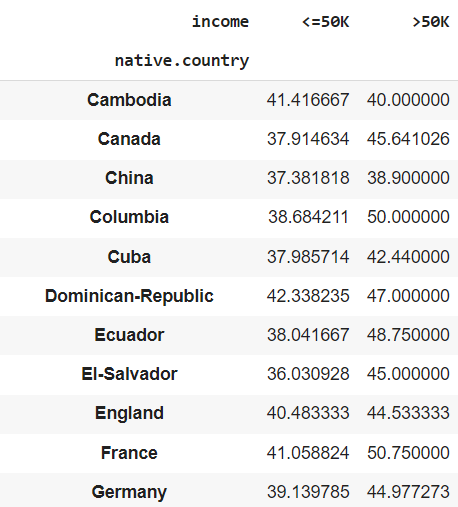

In [285]:
pd.pivot_table(df,
    values = 'hours.per.week',
    index = 'native.country',
    columns='income',
    aggfunc = 'mean'
)

income,<=50K,>50K
native.country,,
Cambodia,41.416667,40.000000
Canada,37.914634,45.641026
China,37.381818,38.900000
Columbia,38.684211,50.000000
Cuba,37.985714,42.440000
Dominican-Republic,42.338235,47.000000
Ecuador,38.041667,48.750000
El-Salvador,36.030928,45.000000
England,40.483333,44.533333


13) Постройте сводную таблицу для сравнения уровня образования и разности между capital.gain и capital.loss по следующему алгоритму:&nbsp;  
1. Создайте вспомогательную таблицу (датафрейм) и добавьте в неё столбец "education" из целевой таблицы
2. Добавьте во вспомогательную таблицу ещё один столбец "capital.diff", значиниями которого будут являться разности столбцов capital.gain и capital.loss целевой таблицы
3. Удалите во вспомогательной таблице все строки, в которых значение столбца "capital.diff" равно нулю  
&nbsp; Подсказка:
```
summary_table = summary_table[summary_table['capital.diff'] != 0 ]
```
4. Для набора значений из столбца "capital.diff", необходимо сформировать 10 категорий (кластеров), это можно сделать с помощью математических функций, типа log, извлечение корня N-ой степени и округления, для последующего перехода к категориальным признакам.  
  * В нашем случае, можно воспользоваться методом [pd.qcut()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.qcut.html) и равномерно разделить наш набор данных на целевое количество категорий
5. Добавьте во вспомогательную таблицу столбец "categories", и проинициализируйте его значениями категорий, которые возвращает метод pd.qcut()  
&nbsp; Пример:
```
summary_table['categories'] = pd.qcut(summary_table["capital.diff"], q = 10)

6. Постройте сводную таблицу с помощью метода pivot_table(),

Примерная структура таблицы (в качестве значений выводится количество людей, относящихся к той или иной группе):

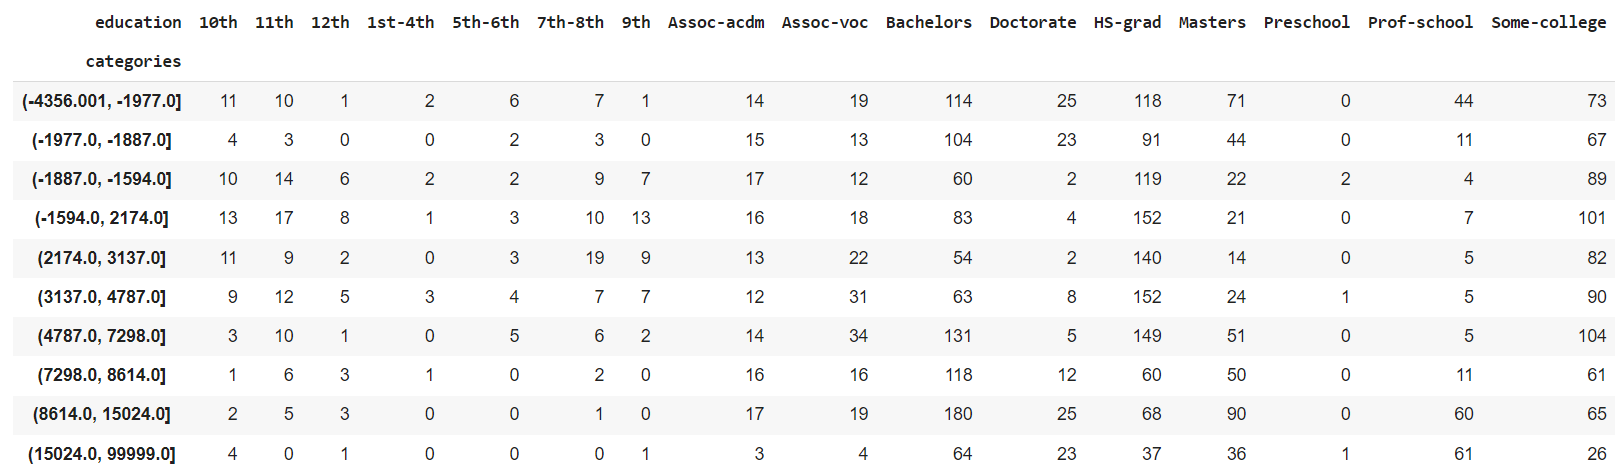

In [317]:
df_new = df[['education']]
df_new['capital.diff'] = df['capital.gain'] - df['capital.loss']
df_new = df_new[df_new['capital.diff'] != 0]
df_new['categories'] = pd.qcut(df_new['capital.diff'], q =10)

pivot = pd.pivot_table(df_new,
    index = 'categories', #строки 
    columns = 'education', # столбцы
    values = 'capital.diff',
    aggfunc = 'count',
    fill_value = 0
)
pivot

education,10th,11th,12th,1st-4th,5th-6th,7th-8th,9th,Assoc-acdm,Assoc-voc,Bachelors,Doctorate,HS-grad,Masters,Preschool,Prof-school,Some-college
categories,,,,,,,,,,,,,,,,
"(-4356.001, -1977.0]",11,10,1,2,6,7,1,14,19,114,25,118,71,0,44,73
"(-1977.0, -1887.0]",4,3,0,0,2,3,0,15,13,104,23,91,44,0,11,67
"(-1887.0, -1594.0]",10,14,6,2,2,9,7,17,12,60,2,119,22,2,4,89
"(-1594.0, 2174.0]",13,17,8,1,3,10,13,16,18,83,4,152,21,0,7,101
"(2174.0, 3137.0]",11,9,2,0,3,19,9,13,22,54,2,140,14,0,5,82
"(3137.0, 4787.0]",9,12,5,3,4,7,7,12,31,63,8,152,24,1,5,90
"(4787.0, 7298.0]",3,10,1,0,5,6,2,14,34,131,5,149,51,0,5,104
"(7298.0, 8614.0]",1,6,3,1,0,2,0,16,16,118,12,60,50,0,11,61
"(8614.0, 15024.0]",2,5,3,0,0,1,0,17,19,180,25,68,90,0,60,65


14) Женщины из каких стран получают в среднем большую зарплату (>50K) чаще.

In [362]:
new_df = df[df['sex'] == ' Female']
new_df = new_df[new_df['income'] == ' >50K']
new_df = new_df[['sex', 'income', 'native.country']]

pivot = pd.pivot_table(new_df,
    index = 'native.country',
    columns = 'income',
    values = 'sex',
    aggfunc= 'count'
)

pivot_sorted = pivot.sort_values(' >50K')

pivot_sorted


income,>50K
native.country,
El-Salvador,1
Honduras,1
Ireland,1
Hungary,1
Hong,1
Greece,1
Haiti,1
Jamaica,1
Scotland,1


15) Создайте случайную колонку - magic_salary, которую нужно будет вычислить следующим образом: если зарплата небольшая (<50K), тогда случайно выберите число из диапазона [0,50]. Если зарплата выше 50K тогда из диапазона [51, 200]. Посчитайте среднюю зарплату в час для групп людей с одни уровнем образования на основе нашей случайной колонки magic_salary

In [385]:
import numpy as np
import random
new_df = df[['sex', 'income', 'hours.per.week', 'education']]
new_df['magic_salary'] = np.where(new_df['income'] == ' <50K', np.random.randint(0, 50, size=len(new_df)), np.random.randint(51, 200, size=len(new_df)))
new_df['cash_in_hor'] = new_df['magic_salary'] // new_df['hours.per.week']

pivot = pd.pivot_table(new_df,
    index = 'education',
    values = 'cash_in_hor',
    aggfunc='mean',
    fill_value=0
)
pivot

,cash_in_hor
education,
10th,4.323687
11th,4.462128
12th,3.808314
1st-4th,3.547619
5th-6th,3.204204
7th-8th,3.729102
9th,3.822957
Assoc-acdm,3.532334
Assoc-voc,3.133864


## Комплексное задание №2. Визуальный анализ данных. Часть 1

In [196]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

В этом задании Вам предлагается провести визуальный анализ датасета о прокатах велосипедов https://www.kaggle.com/c/bike-sharing-demand/data. Оригинальная задача предполагает построение модели предсказания количества прокатов в городе в зависимости от погоды.

Для каждого дня проката известны следующие признаки (как они были указаны в источнике данных):
- season: 1 - весна, 2 - лето, 3 - осень, 4 - зима
- yr: 0 - 2011, 1 - 2012
- mnth: от 1 до 12
- holiday: 0 - нет праздника, 1 - есть праздник
- weekday: от 0 до 6
- workingday: 0 - нерабочий день, 1 - рабочий день
- weathersit: оценка благоприятности погоды от 1 (чистый, ясный день) до 4 (ливень, туман)
- temp: температура в Цельсиях
- atemp: температура по ощущениям в Цельсиях
- hum: влажность
- windspeed(mph): скорость ветра в милях в час
- windspeed(ms): скорость ветра в метрах в секунду
- cnt: количество арендованных велосипедов (это целевой признак, его мы будем предсказывать)

Загрузите самостоятельно(!), с помощью pandas файл `bikes_rent.csv.gz` и выведите первые 5 строк. Ознакомьтесь с данными с помощью функций describe и info.

In [218]:
df = pd.read_csv('bikes_rent.csv')

df.head(5)

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed(mph),windspeed(ms),cnt
0,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,4.805490,985
1,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,7.443949,801
2,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,7.437060,1349
3,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,4.800998,1562
4,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,5.597810,1600


In [388]:
print(df.info())
print()
df.describe

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   season          731 non-null    int64  
 1   yr              731 non-null    int64  
 2   mnth            731 non-null    int64  
 3   holiday         731 non-null    int64  
 4   weekday         731 non-null    int64  
 5   workingday      731 non-null    int64  
 6   weathersit      731 non-null    int64  
 7   temp            731 non-null    float64
 8   atemp           731 non-null    float64
 9   hum             731 non-null    float64
 10  windspeed(mph)  731 non-null    float64
 11  windspeed(ms)   731 non-null    float64
 12  cnt             731 non-null    int64  
dtypes: float64(5), int64(8)
memory usage: 74.4 KB
None



<bound method NDFrame.describe of      season  yr  mnth  holiday  weekday  workingday  weathersit       temp  \
0         1   0     1        0        6           0           2  14.110847   
1         1   0     1        0        0           0           2  14.902598   
2         1   0     1        0        1           1           1   8.050924   
3         1   0     1        0        2           1           1   8.200000   
4         1   0     1        0        3           1           1   9.305237   
..      ...  ..   ...      ...      ...         ...         ...        ...   
726       1   1    12        0        4           1           2  10.420847   
727       1   1    12        0        5           1           2  10.386653   
728       1   1    12        0        6           0           2  10.386653   
729       1   1    12        0        0           0           1  10.489153   
730       1   1    12        0        1           1           2   8.849153   

        atemp      hum  winds

Давайте посмотрим на графиках, как целевой признак зависит количество прокатов (cnt) зависит от остальных признаков `df.columns[:-1]`.

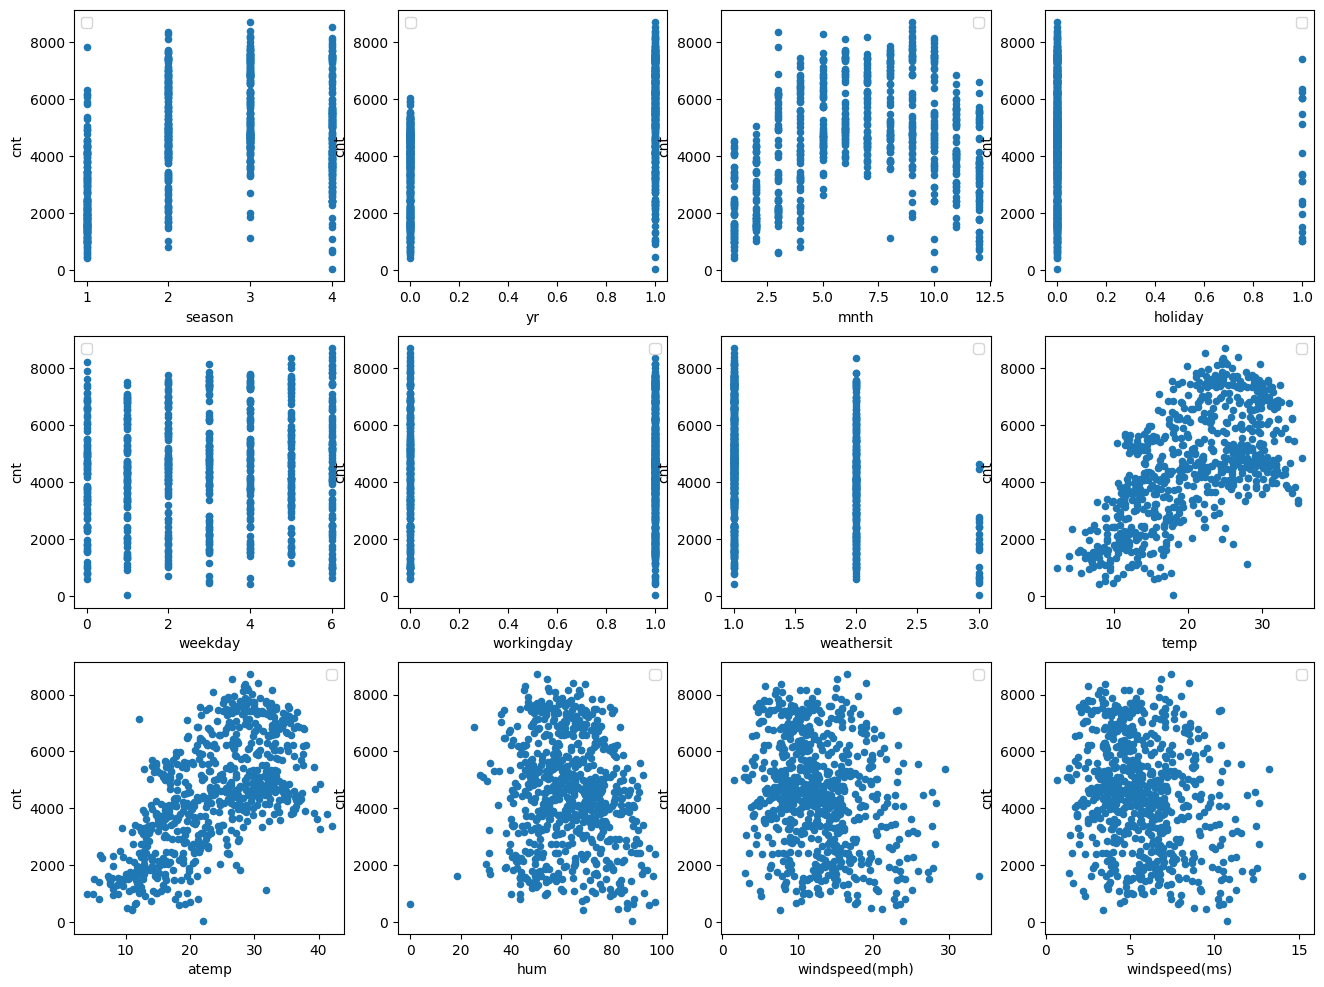

In [389]:
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 12))
for idx, feature in enumerate(df.columns[:-1]):
     df.plot(feature, "cnt", subplots=True, kind="scatter", ax=axes[idx // 4, idx % 4])

### 1. Ответьте на вопросы:

#### Каков характер зависимости числа прокатов от месяца?





ответ: на графике отображающем зависимость числа прокатов от месяца видно, что в каждом месяце велосипеды пользуются спросом, но зимой спрос на прокат низкий, а в течении марта - октября спрос на велосипеды имеет наибольшее значение

#### Укажите один или два признака, от которых число прокатов скорее всего зависит линейно
_(чем больше значение, тем больше прокатов или наоборот, например)_

Можете проверить результат с помощью lnplot.



Ответ: Чем выше темпиратура тем выше шанс того что велосипед возьмут в прокат

### 2. Корреляционная матрица

Напомним, что корреляция отражает взаимосвязь двух случайных величин. Она бывает положительная и отрицательная. Чем ближе коэффициент корреляции к нулю, тем меньше взаимосвязь. Чем больше абсолютная корреляци, тем взаимосвязь больше.

Постройте heatmap корреляционной матрицы. Матрица формируется средствами pandas, со стандартным значением параметров.



<Axes: >

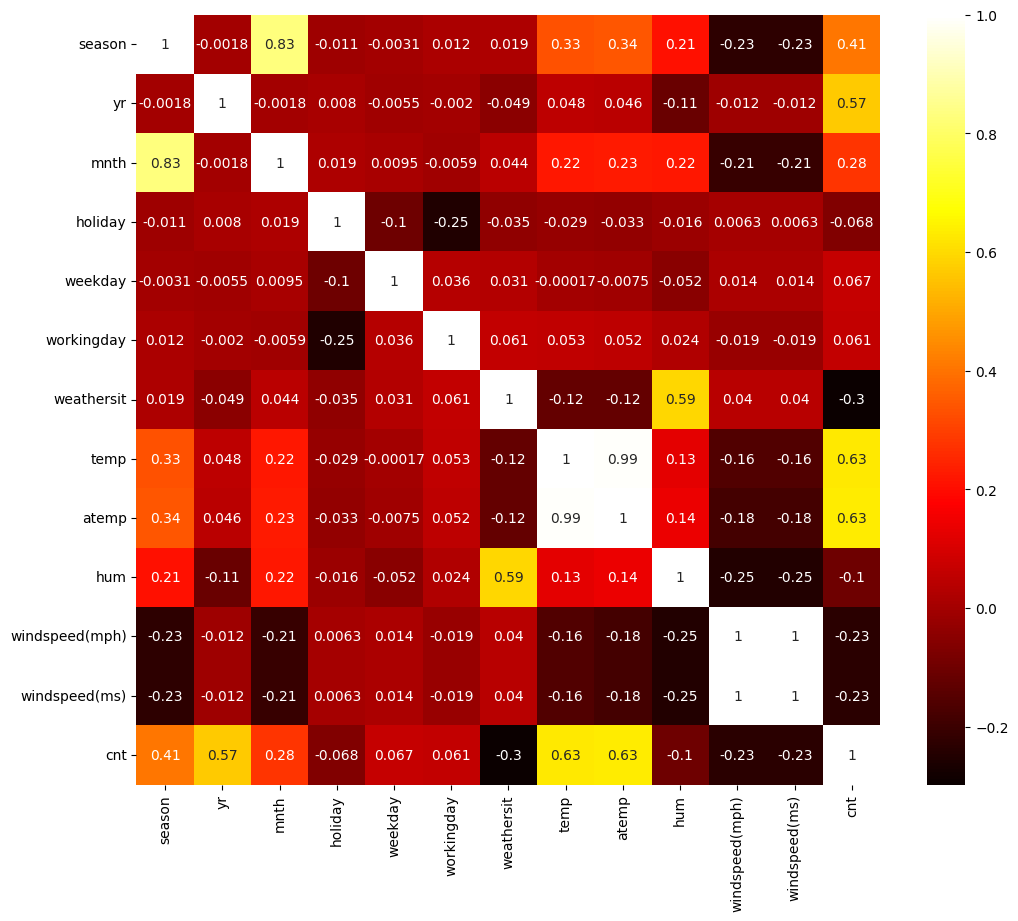

In [403]:
import seaborn as sns
df.corr()
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap='hot')



**Ответьте на вопрос**: с какими признаками количество прокатов коррелирует меньше всего (около 4 штуки). А с какими больше всего?

Ответ: 
Большк всего признак cnt "количество прокатов" коррелирует с:
        -atemp
        -temp
        -yr
        -season
Меньше всего признак cnt "количество прокатов" коррелирует с:
        -workingday
        -weekday
        -holiday
        -hum

### 3. Barpot

Постройте Bar-график суммарного количества прокатов велосипедов по месяцам за каждый год одновременно. (будет 24 столбика)



<Axes: xlabel='mnth', ylabel='cnt'>

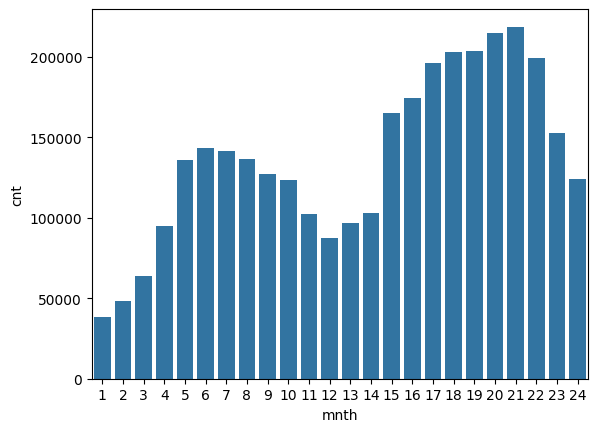

In [219]:
df_new = df[['cnt', 'yr', 'mnth']]
pivot = pd.pivot_table(df_new,
    index = 'mnth',
    columns = 'yr',
    values = 'cnt',
    aggfunc= 'sum'
)

mounth = np.array([i for i in range(1, 25)])
dict_for_bar = {
    'cnt': [*pivot.loc[:, 0], *pivot.loc[:, 1]],
    'mnth': mounth
}
df_for_bar = pd.DataFrame(dict_for_bar)

sns.barplot(data = df_for_bar, y = 'cnt', x = 'mnth')


**Ответьте на вопрос:** почему в предыдущем графике была такая большая корреляция между количеством прокатов и годом?

Ответ:Честно не знаю почему конкретно, предположу что в связи с модой или актуальными новостями велосипеды во втором году больше ценились, видимо в 2011 было меньше желания кататься на велосипеде чем в 2012

### 4. Countplot

Постройте countplot диаграммы для признаков `weekday`, `weathersit`,



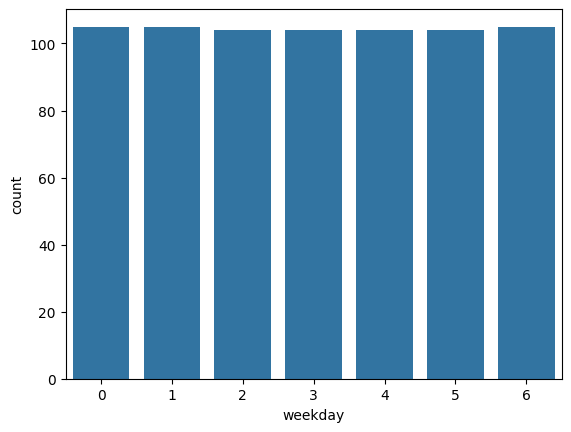

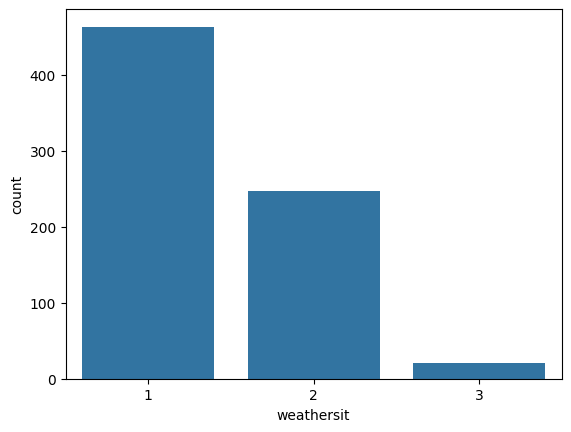

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed(mph),windspeed(ms),cnt
0,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,4.805490,985
1,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,7.443949,801
2,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,7.437060,1349
3,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,4.800998,1562
4,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,5.597810,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,1,1,12,0,4,1,2,10.420847,11.33210,65.2917,23.458911,10.486773,2114
727,1,1,12,0,5,1,2,10.386653,12.75230,59.0000,10.416557,4.656485,3095
728,1,1,12,0,6,0,2,10.386653,12.12000,75.2917,8.333661,3.725374,1341
729,1,1,12,0,0,0,1,10.489153,11.58500,48.3333,23.500518,10.505372,1796


In [469]:
sns.countplot(data = df, x = 'weekday')
plt.show()

sns.countplot(data = df, x = 'weathersit')
plt.show()

**Ответьте на вопрос:** что вы можете сказать о том, как формировался этот датасет.



Ответ:датасет формировался в течение 2 лет и судя по всему начинался формироваться с субботы и закончился формироваться в понедельник потому что по выше указанной диаграмме видно: колонки Вт, Ср, Чт, Пт имеют меньшую высоту чем Cб, Вс, Пн


**Ответьте на вопрос:** как называется распределение значений признака `weekday`?


Ответ: Равномерное распределение

### 5. Распределение

Постройте распределение целевого признака.


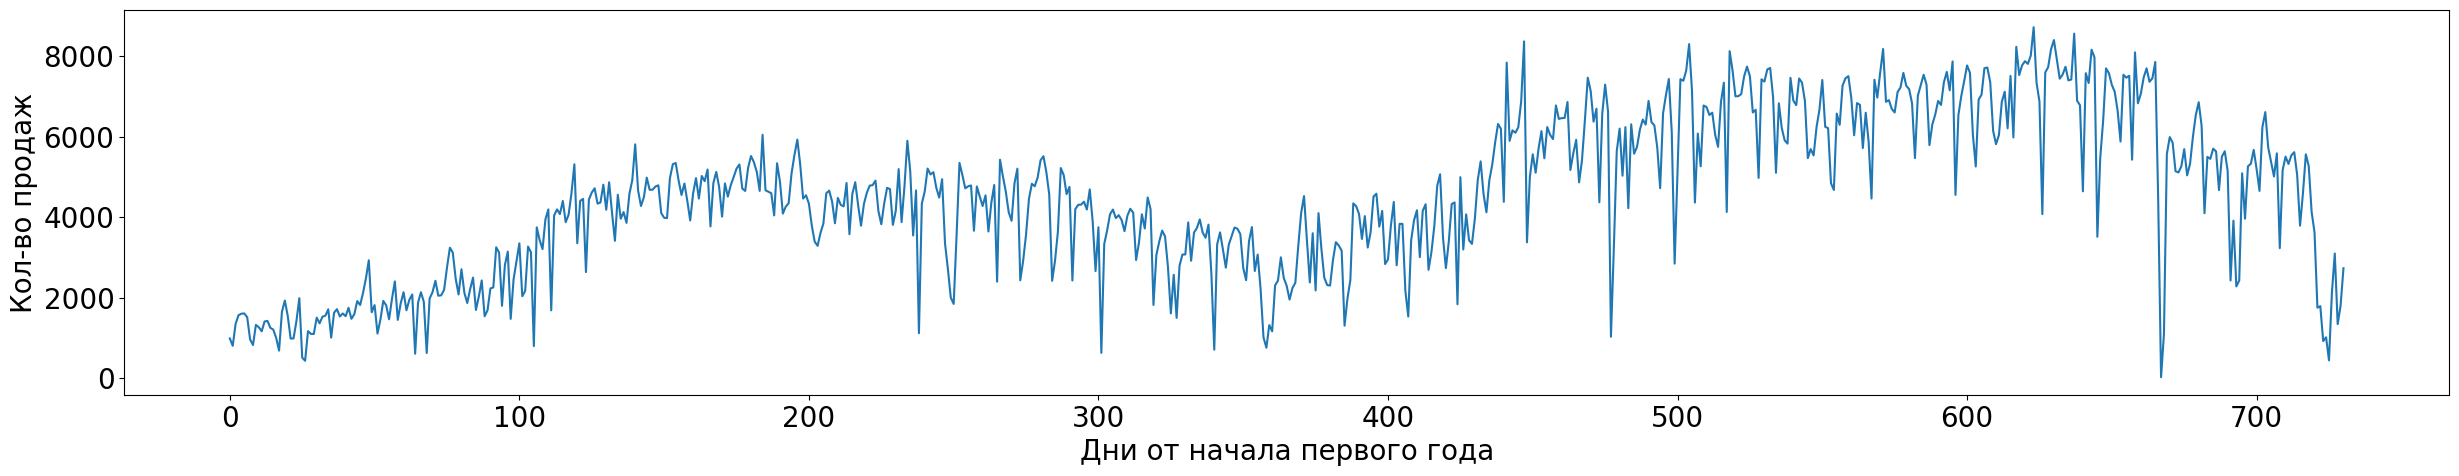

In [502]:
array = np.array([i for i in range(df['cnt'].shape[0])])
dict_for_table = {
    "x": array,
    "y": df['cnt']
}
DataFrame_for_table = pd.DataFrame(dict_for_table)
plt.figure(figsize=(30, 5))
sns.lineplot(data = DataFrame_for_table, x = 'x', y = 'y')
plt.tick_params(labelsize=20)  # размер цифр
plt.xlabel(xlabel = "Дни от начала первого года", fontsize = 20)
plt.ylabel(ylabel = "Кол-во продаж", fontsize = 20)
plt.show()


**Ответьте на вопрос:** основываясь на графике, сколько приблизительно в среднем прокатов бывает в день?

Ответ: В среднем в день около 4500 прокатов

### 6. Совместное распределение признаков

Постройте график совместного распределения признаков температура и ощущение температуры.



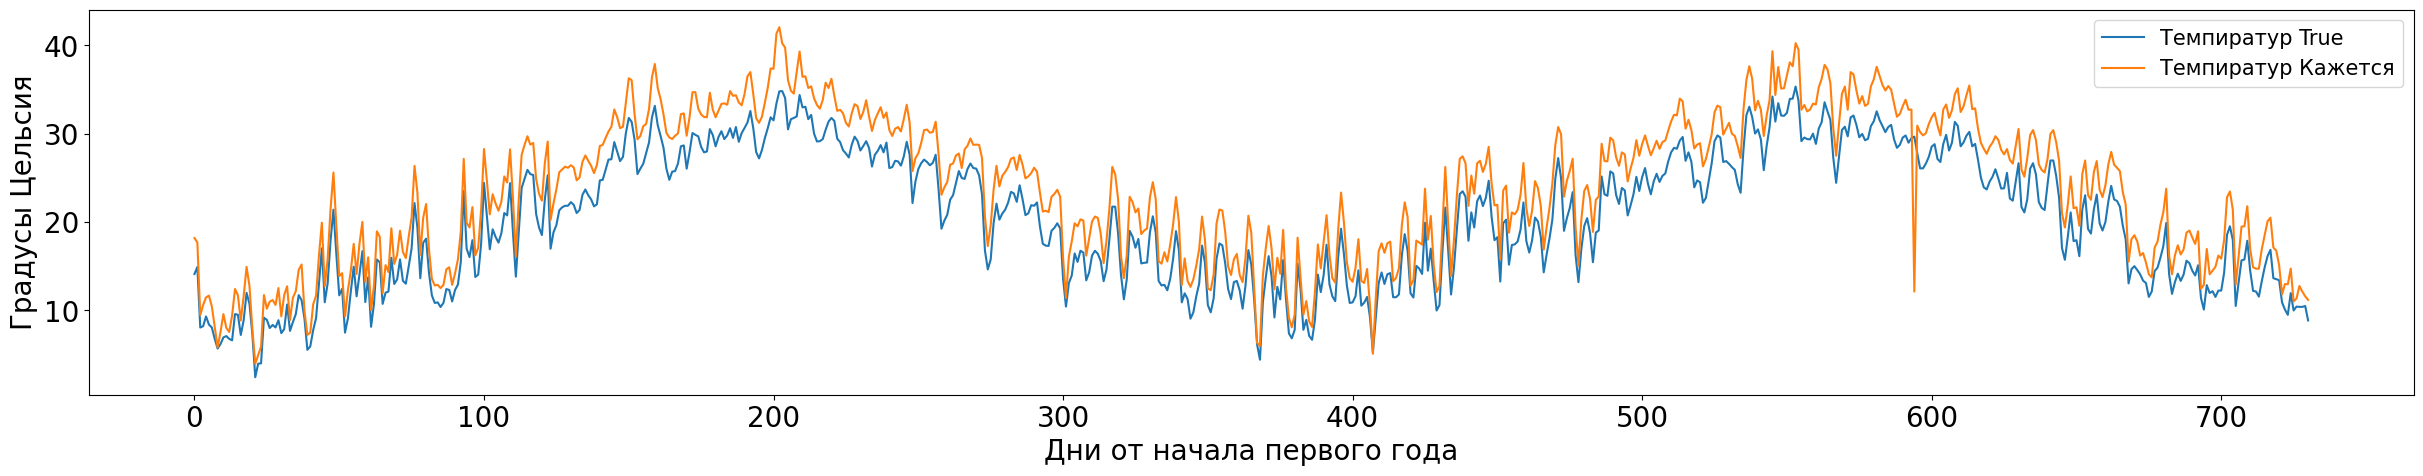

In [525]:
array = np.array([i for i in range(df['temp'].shape[0])])
dict_for_table = {
    "x_1": df['temp'],
    'x_2': df['atemp'],
    "y": array
}
DataFrame_for_table = pd.DataFrame(dict_for_table)

plt.figure(figsize=(30,5))
sns.lineplot(data = DataFrame_for_table, y = 'x_1', x = 'y', label = 'Темпиратур True')
sns.lineplot(data = DataFrame_for_table, y = 'x_2', x = 'y', label = 'Темпиратур Кажется')
plt.tick_params(labelsize = 20)
plt.xlabel(xlabel = "Дни от начала первого года", fontsize = 20)
plt.ylabel(ylabel = 'Градусы Цельсия', fontsize = 20)
plt.legend(fontsize = 15)
plt.show()

**Ответьте на вопрос:** вас в этом графике ничего не настораживает? Почему?

Ответ: Честно говоря сложно что то неестественное заметить в этом графике, предположу только такую закономерность: Почти всегда темпиратура ощущается выше чем она есть на действительности, хотя влажность (и другие параметры) в разные дни может коллебаться

### 7. Боксплот (ящик с усами)

Постройте график распределения (боксплот) количества прокатов велосипедов по месяцам в зависимости от того рабочий это день или нет.




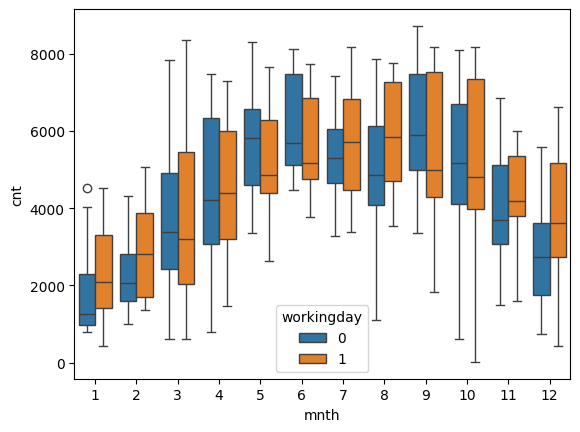

In [212]:
sns.boxplot(data=df, y='cnt', x='mnth', hue = 'workingday')
plt.show()


**Ответьте на вопрос:** почему в некоторых месяцах чаще берут велосипеды в будний день, а в некоторые - в выходной.

Ответ:

## Комплексное задание №3. Визуальный анализ данных. Часть 2

In [1]:
# !pip install seaborn==0.11.0
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [214]:
colab = False # если работаете на своём компьютере, в локальной среде, поставьте False
if colab:
    from google.colab import drive
    drive.mount('/content/drive')

В этом задании Вам предлагается провести визуальный анализ датасета результатов экзаменов студентов  https://www.kaggle.com/spscientist/students-performance-in-exams.

Исходные данные загрузите самостоятельно!

In [220]:
if colab:
    df = pd.read_csv('/content/drive/My Drive/Data/StudentsPerformance.csv')
else:
    df = pd.read_csv("StudentsPerformance.csv")

df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


### Ход задания:

#### 1. Постройте 3 графика, показывающих распределение результатов экзаменов (каждый график на предмет).


Графики должны быть в одном ряду и у них должен быть общий заголовок "Результаты экзаменов".

Для результатов каждого экзамена посчитайте медианные значения.


/var/folders/_4/nx2jj55j4sn3nhsrcjd06_680000gn/T/ipykernel_42542/1062139460.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['math score'], ax=axes[0])
/var/folders/_4/nx2jj55j4sn3nhsrcjd06_680000gn/T/ipykernel_42542/1062139460.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['readin

Mean math score: 66.0
Mean math score: 70.0
Mean math score: 69.0


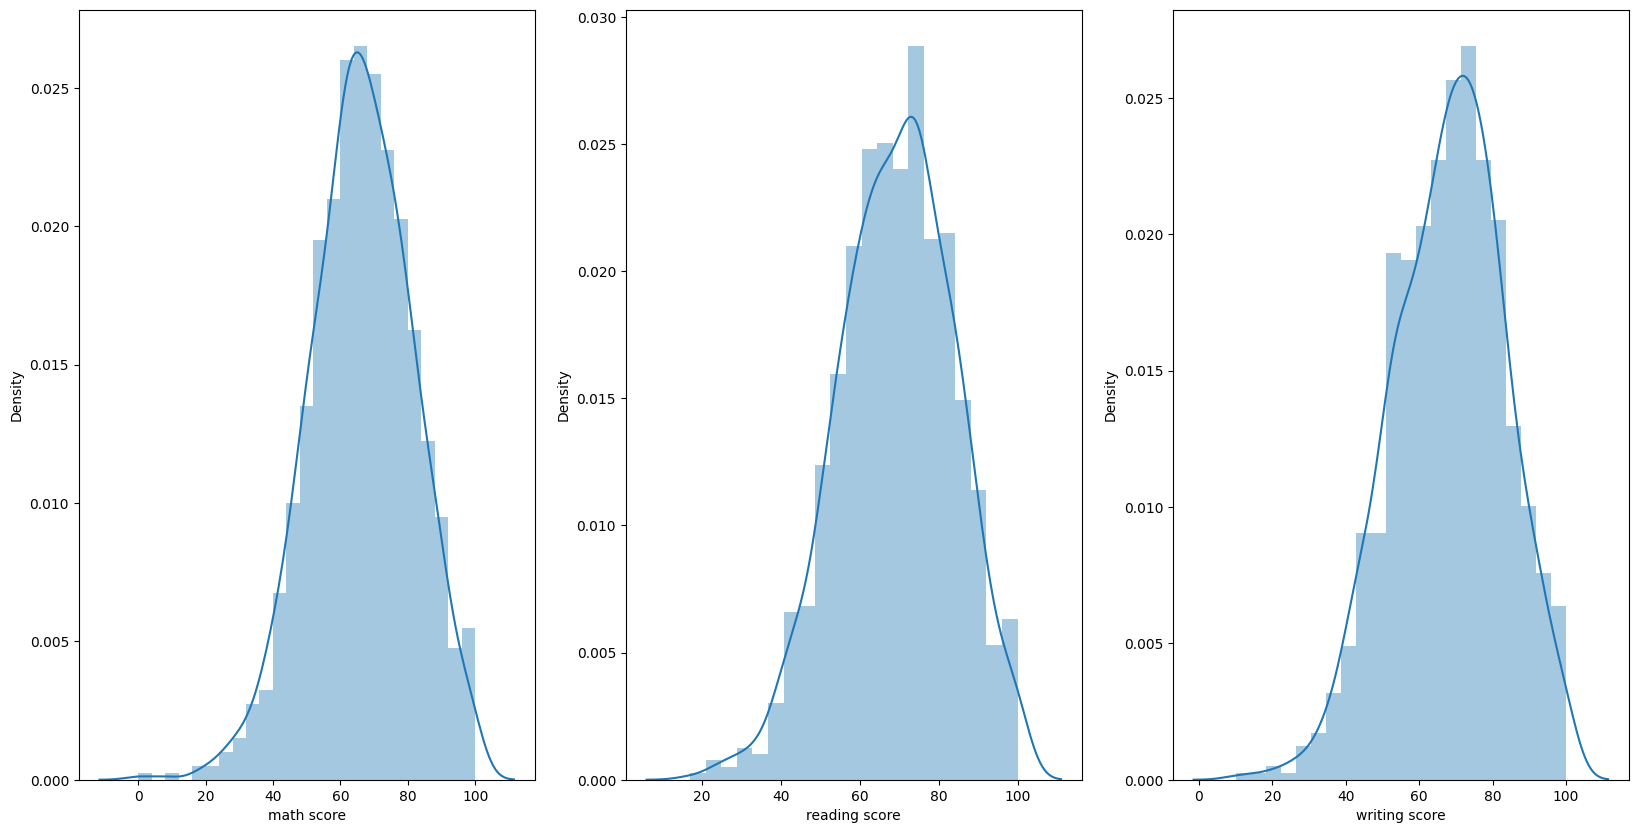

In [146]:
fig, axes = plt.subplots(1, 3, figsize = (20, 10))
sns.distplot(df['math score'], ax=axes[0])
sns.distplot(df['reading score'], ax=axes[1])
sns.distplot(df['writing score'], ax=axes[2])
print("Mean math score:", df['math score'].median())
print("Mean math score:", df['reading score'].median())
print("Mean math score:", df['writing score'].median())


#### 2. Образование родителей
Какие уровни образование есть в столбце *'parental level of education'* и сколько строк в датафрейме соответствует каждому уровню?

Постройте график и ответьте на вопрос ниже

Отличаются ли баллы по математике у детей с разным образованием родителей?
Постройте график, где по оси Х находятся уровни образования родителей, а по У - баллы по математике.


<StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str 


Index(['some college', 'associate's degree', 'high school', 'some high school',
       'bachelor's degree', 'master's degree'],
      dtype='str', name='parental level of education') 




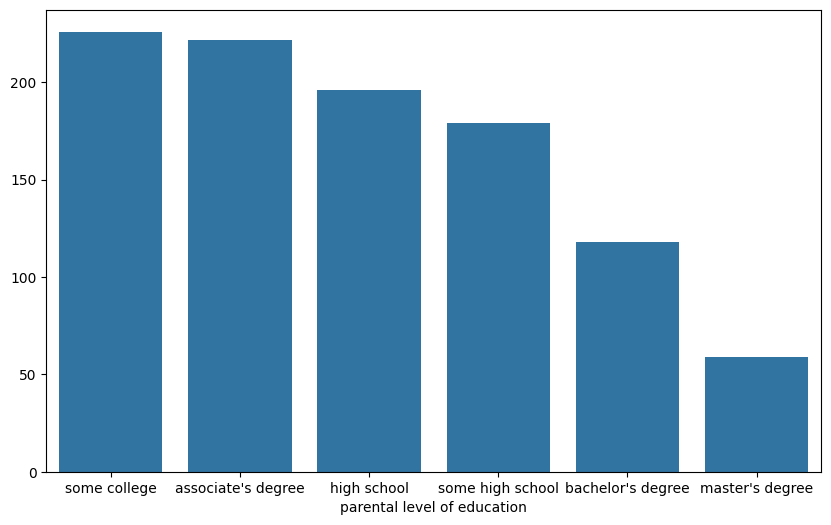

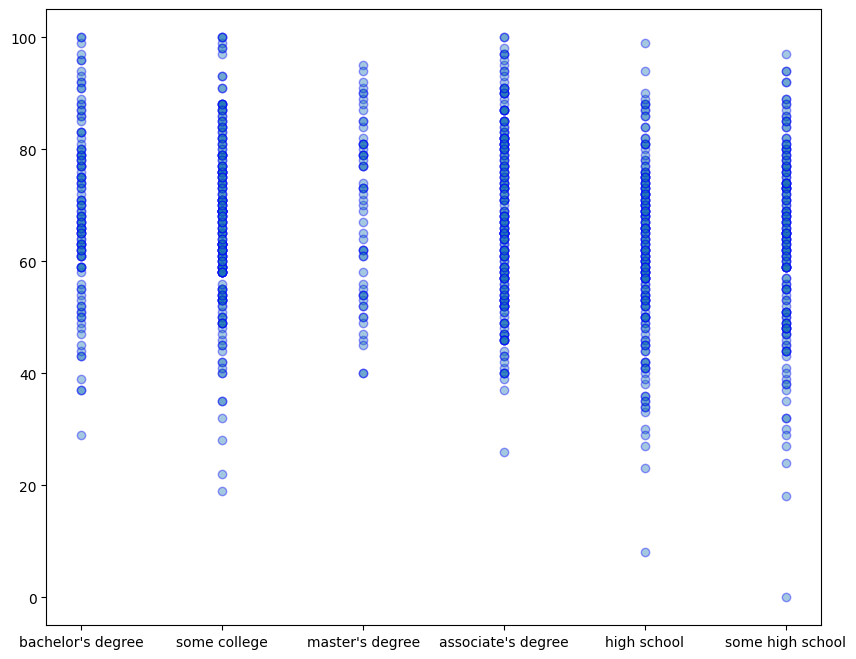

In [20]:
print(df['parental level of education'].unique(), '\n\n')
print(df['parental level of education'].value_counts().index, '\n\n')
fig = plt.figure(figsize=(10, 6))
sns.barplot(x = df['parental level of education'].value_counts().index, y = df['parental level of education'].value_counts().values)
plt.show()

plt.figure(figsize=(10, 8))
plt.scatter(data = df, x = 'parental level of education', y = 'math score', alpha = 0.4, edgecolors = 'blue')



#### 3. Выведите число студенток, набравших больше 90 баллов по всем предметам.


In [45]:
student_female_who_more_90 = df.loc[(df['gender'] == 'female') &
   (df['math score'] > 90) &
   (df['writing score'] > 90) & 
   (df['reading score'] > 90)
]
print(len(student_female_who_more_90))
student_female_who_more_90


17


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
114,female,group E,bachelor's degree,standard,completed,99,100,100
165,female,group C,bachelor's degree,standard,completed,96,100,100
179,female,group D,some high school,standard,completed,97,100,100
451,female,group E,some college,standard,none,100,92,97
458,female,group E,bachelor's degree,standard,none,100,100,100
546,female,group A,some high school,standard,completed,92,100,97
566,female,group E,bachelor's degree,free/reduced,completed,92,100,100
594,female,group C,bachelor's degree,standard,completed,92,100,99
685,female,group E,master's degree,standard,completed,94,99,100
712,female,group D,some college,standard,none,98,100,99


#### 4. Сравните баллы у студентов разных полов. Используя agg() выведите минимальное, максимальное и медианное значение


для male
grade:	writing:  reading:  math:
min	15	23	27
median	64.0	66.0	69.0
max	100	100	100

для female
grade:	writing:  reading:  math:
min	10	17	0
median	74.0	73.0	65.0
max	100	100	100


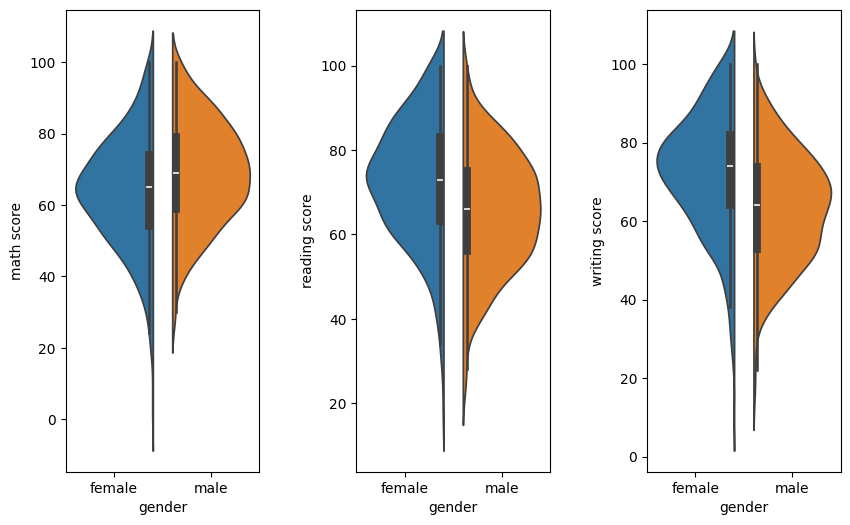

In [133]:
fig, axes = plt.subplots(1, 3, figsize = (10, 6))

sns.violinplot(data = df, y = 'math score', x = 'gender',  hue = 'gender', split = True, ax=axes[0])
sns.violinplot(data = df, y = 'reading score', x = 'gender',  hue = 'gender', split = True, ax=axes[1])
sns.violinplot(data = df, y = 'writing score', x = 'gender',  hue = 'gender', split = True, ax=axes[2])
plt.subplots_adjust(wspace=0.5)

print("для male")
print("grade:\twriting:  reading:  math:")
print(f"min\t{df.loc[df['gender'] == 'male', 'writing score'].agg('min')}\t{df.loc[df['gender'] == 'male', 'reading score'].agg('min')}\t{df.loc[df['gender'] == 'male', 'math score'].agg('min')}")
print(f"median\t{df.loc[df['gender'] == 'male', 'writing score'].agg('median')}\t{df.loc[df['gender'] == 'male', 'reading score'].agg('median')}\t{df.loc[df['gender'] == 'male', 'math score'].agg('median')}")
print(f"max\t{df.loc[df['gender'] == 'male', 'writing score'].agg('max')}\t{df.loc[df['gender'] == 'male', 'reading score'].agg('max')}\t{df.loc[df['gender'] == 'male', 'math score'].agg('max')}")

print("\nдля female")
print("grade:\twriting:  reading:  math:")
print(f"min\t{df.loc[df['gender'] == 'female', 'writing score'].agg('min')}\t{df.loc[df['gender'] == 'female', 'reading score'].agg('min')}\t{df.loc[df['gender'] == 'female', 'math score'].agg('min')}")
print(f"median\t{df.loc[df['gender'] == 'female', 'writing score'].agg('median')}\t{df.loc[df['gender'] == 'female', 'reading score'].agg('median')}\t{df.loc[df['gender'] == 'female', 'math score'].agg('median')}")
print(f"max\t{df.loc[df['gender'] == 'female', 'writing score'].agg('max')}\t{df.loc[df['gender'] == 'female', 'reading score'].agg('max')}\t{df.loc[df['gender'] == 'female', 'math score'].agg('max')}")


#### 5. Выясните, влияет ли обед и подготовка к тесту на средний балл студентов разного пола
###### (подсказка: используете  [pd.agg()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.agg.html))

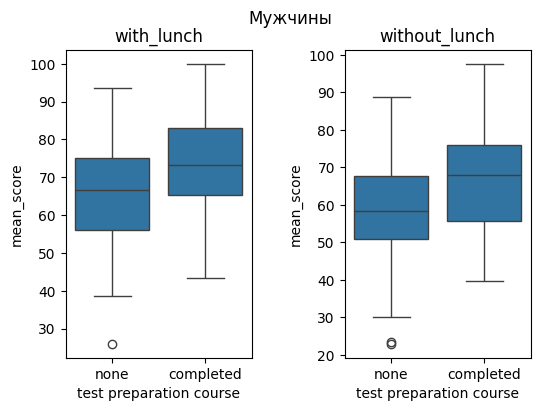

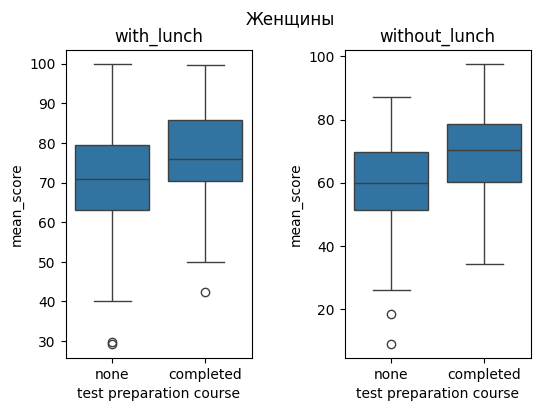

In [193]:
fig, axes = plt.subplots(1, 2, figsize = (6, 4))
plt.subplots_adjust(wspace=0.5)

male_with_lunch = df[(df['gender'] == 'male') & (df['lunch'] == 'standard')]
male_with_lunch['mean_score'] = male_with_lunch[['math score', 'reading score', 'writing score']].mean(axis=1)

male_without_lunch = df[(df['gender'] == 'male') & (df['lunch'] == 'free/reduced')]
male_without_lunch['mean_score'] = male_without_lunch[['math score', 'reading score', 'writing score']].mean(axis=1)

sns.boxplot(data = male_with_lunch, x = 'test preparation course', y = 'mean_score', ax=axes[0]) 
axes[0].set_title('with_lunch')
sns.boxplot(data = male_without_lunch, x = 'test preparation course', y = 'mean_score', ax=axes[1])
axes[1].set_title('without_lunch') 
plt.suptitle("Мужчины")
plt.show()

fig, axes = plt.subplots(1, 2, figsize = (6, 4))
plt.subplots_adjust(wspace=0.5)

female_with_lunch = df[(df['gender'] == 'female') & (df['lunch'] == 'standard')]
female_with_lunch['mean_score'] = female_with_lunch[['math score', 'reading score', 'writing score']].mean(axis=1)

female_without_lunch = df[(df['gender'] == 'female') & (df['lunch'] == 'free/reduced')]
female_without_lunch['mean_score'] = female_without_lunch[['math score', 'reading score', 'writing score']].mean(axis=1)

sns.boxplot(data = female_with_lunch, x = 'test preparation course', y = 'mean_score', ax=axes[0]) 
axes[0].set_title('with_lunch')
sns.boxplot(data = female_without_lunch, x = 'test preparation course', y = 'mean_score', ax=axes[1])
axes[1].set_title('without_lunch') 
plt.suptitle("Женщины")
plt.show()

#### 6. Постройте график, показывающий зависимость уровня образования родителей от их расы

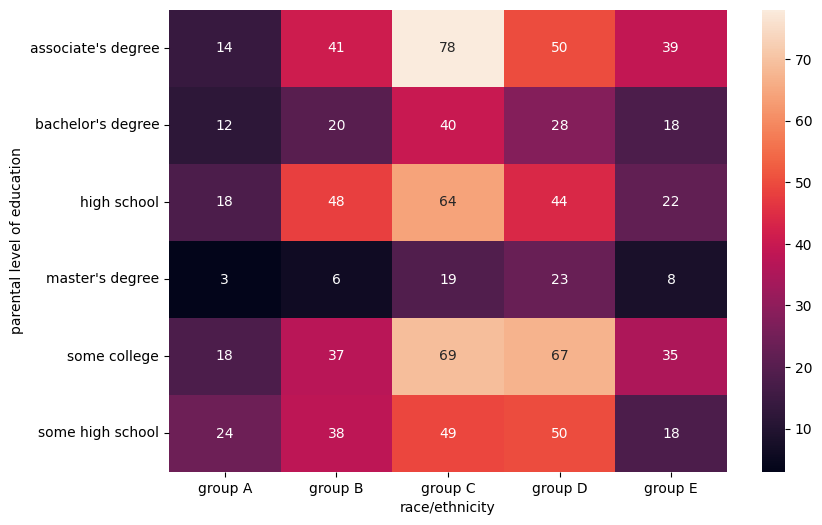

In [263]:
pivot = pd.pivot_table(df,
    index = 'parental level of education',
    columns = 'race/ethnicity',
    values = 'gender',
    aggfunc = 'count'
)

f, ax = plt.subplots(figsize = (9,6))
sns.heatmap(data=pivot, annot=True)
plt.show()

#### 7. Постройте график, показывающий зависимость прохождения подготовительного теста от уровня образования родителей.


Кто чаще ходит на курсы: дети, родители которых закончили только старшую школу, или дети, чьи родители получили степень бакалавра\магистра?

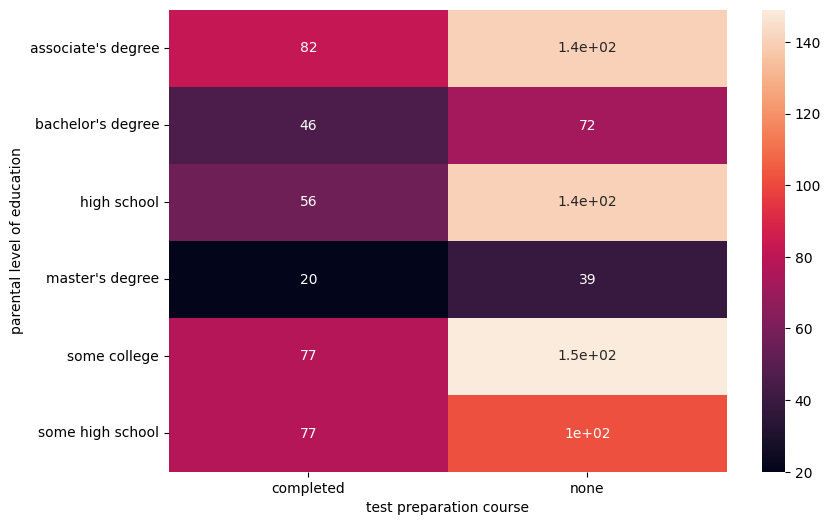

In [262]:
pivot = pd.pivot_table(df,
    index = 'parental level of education',
    columns = 'test preparation course',
    values = 'gender',
    aggfunc = 'count'
)

f, ax = plt.subplots(figsize = (9,6))
sns.heatmap(data=pivot, annot=True)
plt.show()

#### 8. Постройте plot.pie, показывающий, сколько людей сдали\не сдали экзамен по математике.

Сдавшим считается человек, набравший 40 баллов.

###### Подсказка: создайте столбец в датафрейме, который содержит результат сдачи (сдал или не сдал)

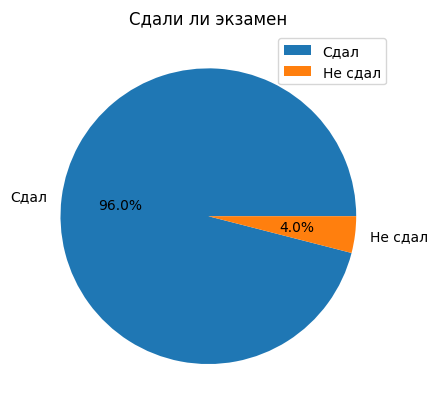

In [276]:
new_df = df 
new_df['complete_math'] = np.where(new_df['math score'] > 39, 'Сдал', 'Не сдал')

table_df = df['complete_math'].value_counts()

table_df.plot.pie(autopct='%1.1f%%')
plt.title('Сдали ли экзамен')
plt.legend()
plt.show()

#### 9. Постройте plot.pie, показывающий распределение студентов по оценкам

Оценки студентов выставляются по шкале:<br>
0  - 40 marks : grade E<br>
41 - 60 marks : grade D<br>
60 - 70 marks : grade C<br>
70 - 80 marks : grade B<br>
80 - 90 marks : grade A<br>
90 - 100 marks : grade O<br>

Для этого посчитайте сумму результатов за 3 экзамена и найдите среднее. Оценка выставляется по среднему значению. Если студент не сдал математику(даже если средний балл выше 40), он получает Е

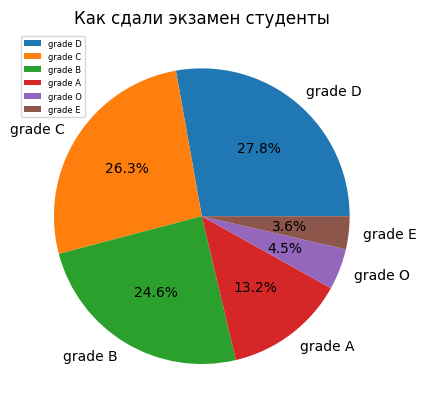

In [302]:
new_df = df 
new_df['math'] = np.where(new_df['math score'] > 40, new_df['math score'], -200)
new_df['exams score'] = (new_df['math score'] + new_df['writing score'] + new_df['reading score']) /3

bins = [0, 41, 61, 71, 81, 91, 101]
labels = ['grade E', 'grade D', 'grade C', 'grade B', 'grade A', 'grade O']

new_df['complete_exams'] = pd.cut(new_df['exams score'], bins = bins, labels = labels)


table_df = new_df['complete_exams'].value_counts()

table_df.plot.pie(autopct='%1.1f%%')
plt.title('Как сдали экзамен студенты')
plt.legend(fontsize=6)
plt.show()

#### 10. Постройте countplot, показывающий зависимость между итоговой оценкой студентов и его полом. Студенты какого пола получили больше оценок О, А, В

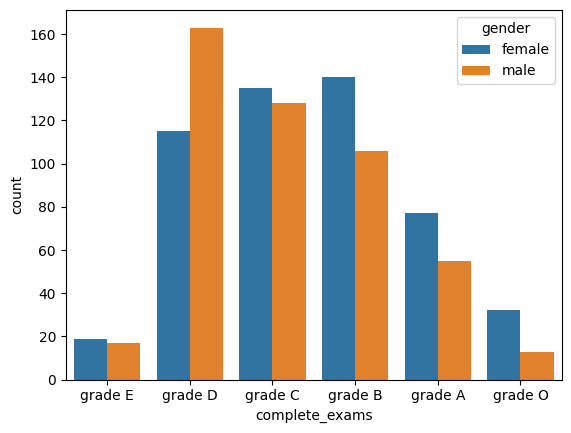

In [309]:
sns.countplot(data = new_df, x = 'complete_exams', hue = 'gender')
plt.show()